In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore, stats

In [3]:
df = pd.read_csv("Ecommerce_Sales_Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.head()

,Date,Product_Category,Price,Discount,Customer_Segment,Marketing_Spend,Units_Sold
0,2023-01-01,Sports,932.80,35.82,Occasional,6780.38,32
1,2023-01-02,Toys,569.48,3.60,Premium,6807.56,16
2,2023-01-03,Home Decor,699.68,3.56,Premium,3793.91,27
3,2023-01-04,Toys,923.27,0.61,Premium,9422.75,29
4,2023-01-05,Toys,710.17,47.83,Premium,1756.83,17


In [4]:
Product_Category_Count = df['Product_Category'].value_counts()
Product_Category_Perd = (Product_Category_Count / Product_Category_Count.sum()) * 100
Frequency = pd.DataFrame({'Count': Product_Category_Count,'Percentage': Product_Category_Perd})

print("Frequency distribution of product category:")
Frequency

Frequency distribution of product category:


,Count,Percentage
Product_Category,,
Electronics,210,21.0
Sports,206,20.6
Toys,204,20.4
Home Decor,190,19.0
Fashion,190,19.0


In [5]:
mean_values = df[['Price', 'Discount', 'Marketing_Spend']].mean()
print(f"Mean of decimal values:\n{mean_values}")
print(f"\nMedian of units sold: {df['Units_Sold'].median()}")
print(f"\nMost frequent customer segment: {df['Customer_Segment'].mode()[0]}")

Mean of decimal values:
Price               505.24192
Discount             24.91975
Marketing_Spend    4912.83024
dtype: float64

Median of units sold: 30.0

Most frequent customer segment: Regular


In [6]:
numerical = df[['Price', 'Discount', 'Marketing_Spend', 'Units_Sold']]
print("Range of numerical values:")
print(numerical.max() - numerical.min())
print("\nStandard Deviation:")
print(numerical.std())
print("\nVariance:")
print(numerical.var())

Range of numerical values:
Price               984.83
Discount             49.91
Marketing_Spend    9895.32
Units_Sold           52.00
dtype: float64

Standard Deviation:
Price               289.791248
Discount             14.439951
Marketing_Spend    2840.602656
Units_Sold            7.267989
dtype: float64

Variance:
Price              8.397897e+04
Discount           2.085122e+02
Marketing_Spend    8.069023e+06
Units_Sold         5.282366e+01
dtype: float64


In [7]:
print("Quartiles for numerical values:")
print(numerical.quantile([0.25, 0.5, 0.75]))

Quartiles for numerical values:
         Price  Discount  Marketing_Spend  Units_Sold
0.25  243.3425   12.9950         2413.020        24.0
0.50  509.3100   24.9650         4837.245        30.0
0.75  747.5925   37.5625         7319.675        34.0


In [8]:
Q1 = numerical.quantile(0.25)
Q3 = numerical.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numerical < (Q1 - 1.5 * IQR)) | ((numerical > (Q3 + 1.5 * IQR))))
print("Number of outliers in each column:")
print(outliers.sum())

Number of outliers in each column:
Price              0
Discount           0
Marketing_Spend    0
Units_Sold         5
dtype: int64


In [9]:
pd.crosstab(df["Product_Category"], df["Customer_Segment"], margins=True)

Customer_Segment,Occasional,Premium,Regular,All
Product_Category,,,,
Electronics,66,62,82,210
Fashion,67,60,63,190
Home Decor,69,59,62,190
Sports,62,68,76,206
Toys,75,67,62,204
All,339,316,345,1000


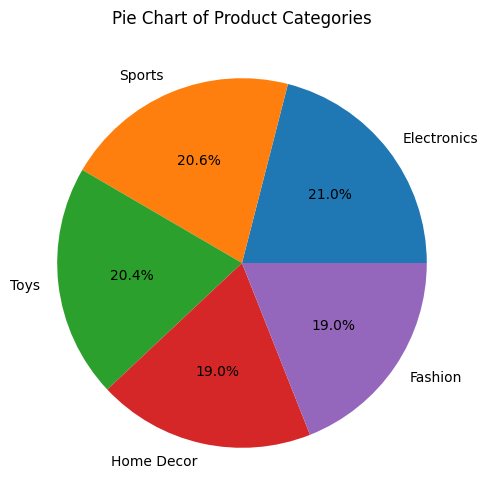

In [10]:
Product_Category_counts = df['Product_Category'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(Product_Category_counts, labels=Product_Category_counts.index, autopct='%1.1f%%')
plt.title('Pie Chart of Product Categories')
plt.show()

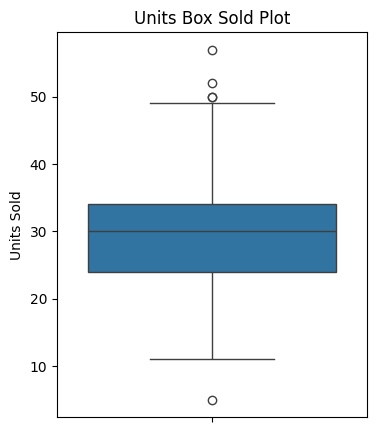

In [11]:
plt.figure(figsize=(4, 5))
sns.boxplot(data=df, y=df["Units_Sold"])
plt.title('Units Box Sold Plot')
plt.ylabel('Units Sold')
plt.show()

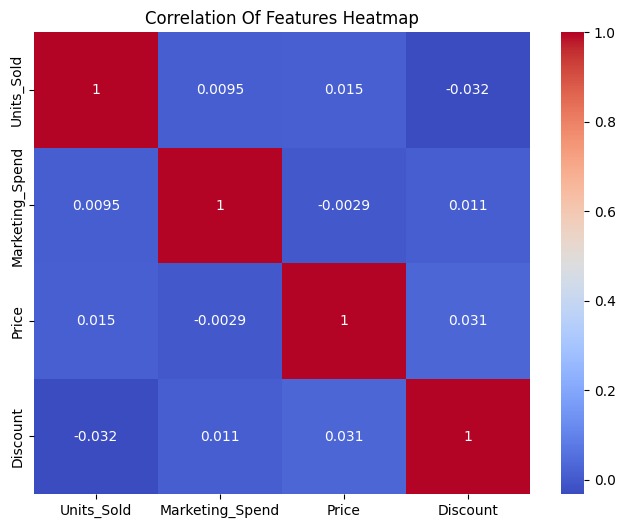

In [12]:
list = ['Units_Sold', 'Marketing_Spend', 'Price', 'Discount']
plt.figure(figsize=(8, 6))
sns.heatmap(df[list].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Of Features Heatmap")
plt.show()

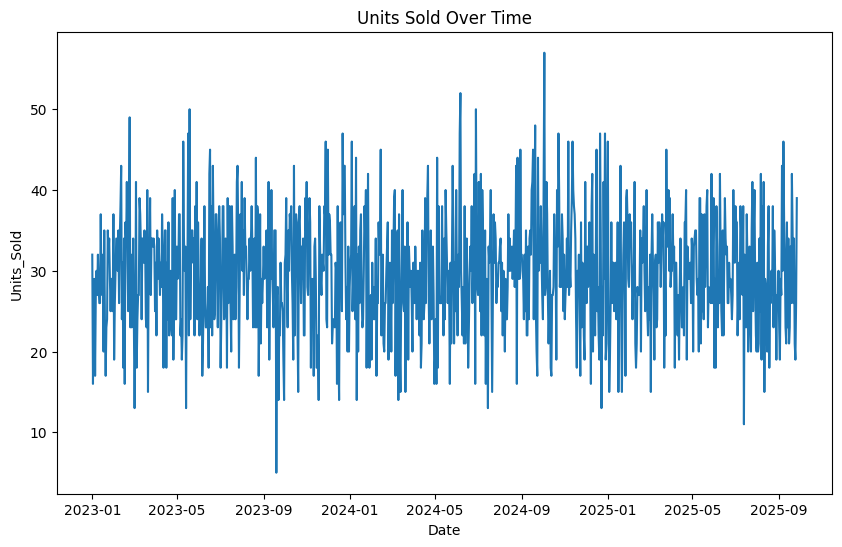

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df["Date"], df["Units_Sold"])
plt.title('Units Sold Over Time')
plt.xlabel('Date')
plt.ylabel('Units_Sold')
plt.show()

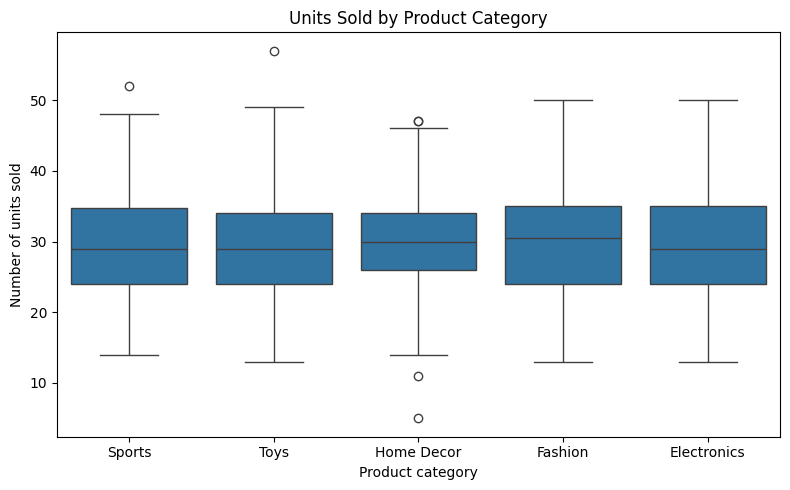

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Product_Category", y="Units_Sold")
plt.title("Units Sold by Product Category")
plt.xlabel("Product category")
plt.ylabel("Number of units sold")
plt.tight_layout()
plt.show()

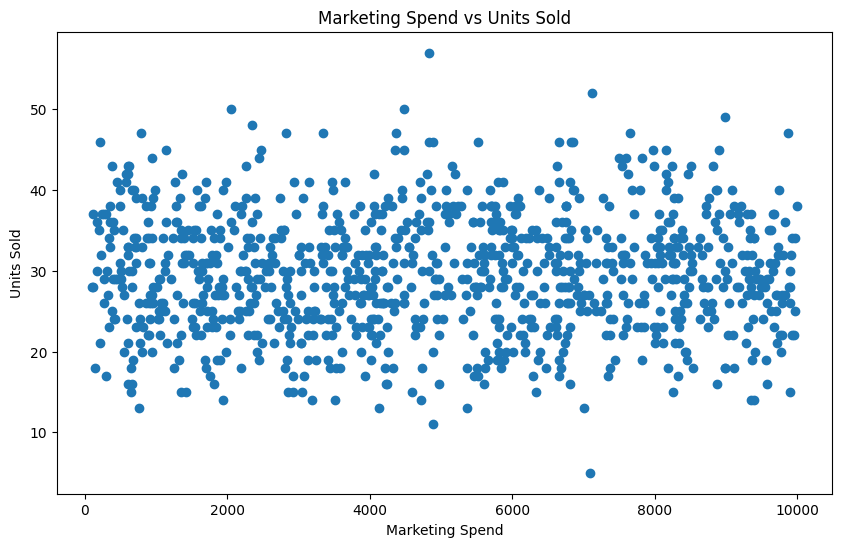

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Marketing_Spend'], df['Units_Sold'])
plt.title('Marketing Spend vs Units Sold')
plt.xlabel('Marketing Spend')
plt.ylabel('Units Sold')
plt.show()